In [33]:
%pip install pandas numpy scikit-learn xgboost matplotlib seaborn


  Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl (8.1 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.61.1-cp311-cp311-macosx_10_9_universal2.whl (2.9 MB)
  Using cached kiwisolver-1.4.9-cp311-cp311-macosx_11_0_arm64.whl (65 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


In [ ]:
df = pd.read_csv("../Dataset/cardekho_imputated.csv")

df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [41]:
df.info()
df.describe()
df.corr()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  int64  
 1   brand              15411 non-null  int64  
 2   model              15411 non-null  int64  
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  int64  
 6   fuel_type          15411 non-null  int64  
 7   transmission_type  15411 non-null  int64  
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(11)
memory usage: 1.5 MB


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
car_name,1.000000,0.988476,0.217583,-0.007248,0.089445,0.022395,-0.087596,0.075123,-0.050724,0.069898,-0.098084,0.273101,-0.056979
brand,0.988476,1.000000,0.110821,-0.018012,0.092196,0.023379,-0.097846,0.065918,-0.071484,0.101665,-0.085699,0.310245,-0.049755
model,0.217583,0.110821,1.000000,0.033645,0.025116,0.037883,-0.020672,0.154569,0.001098,-0.080132,-0.104738,0.019894,-0.110702
vehicle_age,-0.007248,-0.018012,0.033645,1.000000,0.333891,-0.056234,-0.007613,0.080711,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,0.089445,0.092196,0.025116,0.333891,1.000000,0.036078,-0.245421,0.073501,-0.105239,0.192885,0.044421,0.192830,-0.080030
seller_type,0.022395,0.023379,0.037883,-0.056234,0.036078,1.000000,0.046451,0.197564,0.082295,-0.120694,-0.184449,0.039560,-0.137198
fuel_type,-0.087596,-0.097846,-0.020672,-0.007613,-0.245421,0.046451,1.000000,0.005156,-0.155834,-0.447268,-0.258257,-0.329337,-0.217803
transmission_type,0.075123,0.065918,0.154569,0.080711,0.073501,0.197564,0.005156,1.000000,0.282738,-0.348607,-0.539448,0.058527,-0.459394
mileage,-0.050724,-0.071484,0.001098,-0.257394,-0.105239,0.082295,-0.155834,0.282738,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,0.069898,0.101665,-0.080132,0.098965,0.192885,-0.120694,-0.447268,-0.348607,-0.632987,1.000000,0.807368,0.551236,0.585844


In [9]:
df.isnull().sum()


Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [10]:
df = pd.read_csv("../cardekho_imputated.csv")

df.head()


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


In [13]:
categorical_cols = [
    'car_name',
    'brand',
    'model',
    'seller_type',
    'fuel_type',
    'transmission_type'
]

numerical_cols = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]


In [14]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,65,18,7,9,120000,1,4,1,19.70,796,46.30,5,120000
1,34,8,54,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,40,8,118,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,65,18,7,9,37000,1,4,1,20.92,998,67.10,5,226000
4,20,6,38,6,30000,0,1,1,22.77,1498,98.59,5,570000


In [15]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

X.shape, y.shape


((15411, 12), (15411,))

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [25]:
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [26]:
y_pred = xgb_model.predict(X_test)

y_pred[:10]


array([2.2903106e+05, 6.6381375e+05, 6.2838231e+05, 1.2457125e+06,
       1.8677055e+05, 4.9902494e+05, 4.2858328e+05, 2.7614041e+05,
       3.6430369e+05, 1.0403245e+06], dtype=float32)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mae


97403.9140625

In [28]:
mse = mean_squared_error(y_test, y_pred)
mse


72239972352.0

In [29]:
rmse = np.sqrt(mse)
rmse


np.float64(268774.94740395725)

In [30]:
r2 = r2_score(y_test, y_pred)
r2


0.9040359854698181

In [ ]:
n = X_test.shape[0]      # number of test samples
p = X_test.shape[1]      # number of features

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2

0.9036608818299607

<Figure size 1000x600 with 0 Axes>

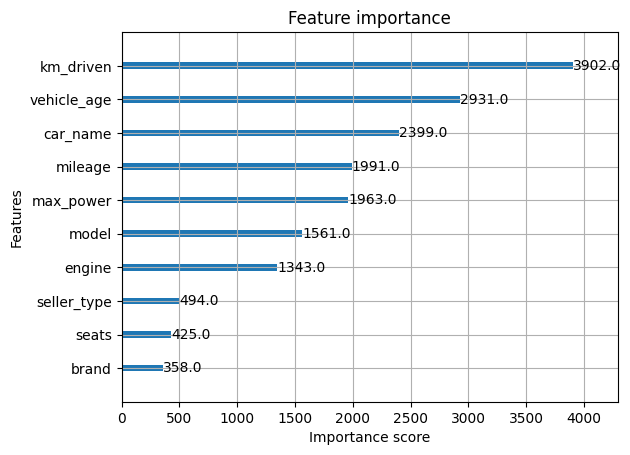

In [35]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(xgb_model, max_num_features=10)
plt.show()


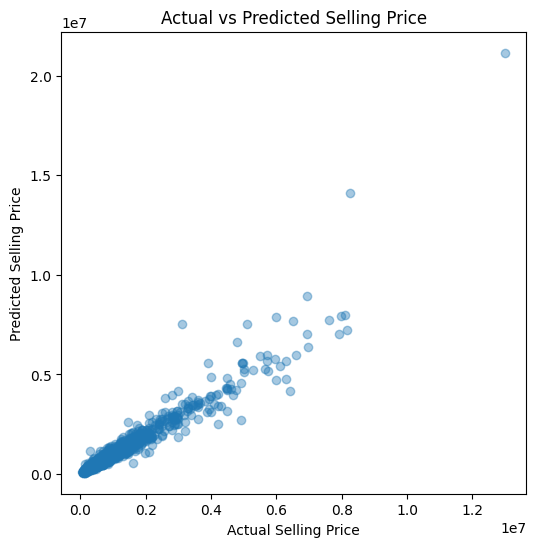

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()


In [37]:
sample_car = X_test.iloc[0].values.reshape(1, -1)
predicted_price = xgb_model.predict(sample_car)

predicted_price


array([229031.06], dtype=float32)